In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anderas/car-consume/gas_station_orig.jpg
/kaggle/input/datasets/anderas/car-consume/measurements2.xlsx
/kaggle/input/datasets/anderas/car-consume/measurements.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/datasets/anderas/car-consume/measurements.csv")

In [4]:
df.head()

,distance,consume,speed,temp_inside,temp_outside,specials,gas_type,AC,rain,sun,refill liters,refill gas
0,28,5,26,"21,5",12,NaN,E10,0,0,0,45,E10
1,12,"4,2",30,"21,5",13,NaN,E10,0,0,0,NaN,NaN
2,"11,2","5,5",38,"21,5",15,NaN,E10,0,0,0,NaN,NaN
3,"12,9","3,9",36,"21,5",14,NaN,E10,0,0,0,NaN,NaN
4,"18,5","4,5",46,"21,5",15,NaN,E10,0,0,0,NaN,NaN


In [5]:
cols_to_fix = ['distance', 'consume', 'temp_inside', 'refill liters']

for col in cols_to_fix:
    df[col] = (
        df[col]
        .astype(str)               # paksa semua jadi string dulu
        .str.replace(',', '.', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance       388 non-null    float64
 1   consume        388 non-null    float64
 2   speed          388 non-null    int64  
 3   temp_inside    376 non-null    float64
 4   temp_outside   388 non-null    int64  
 5   specials       93 non-null     object 
 6   gas_type       388 non-null    object 
 7   AC             388 non-null    int64  
 8   rain           388 non-null    int64  
 9   sun            388 non-null    int64  
 10  refill liters  13 non-null     float64
 11  refill gas     13 non-null     object 
dtypes: float64(4), int64(5), object(3)
memory usage: 36.5+ KB


In [7]:
df.describe()

,distance,consume,speed,temp_inside,temp_outside,AC,rain,sun,refill liters
count,388.000000,388.000000,388.000000,376.000000,388.000000,388.000000,388.000000,388.000000,13.000000
mean,19.652835,4.912371,41.927835,21.929521,11.358247,0.077320,0.123711,0.082474,37.115385
std,22.667837,1.033172,13.598524,1.010455,6.991542,0.267443,0.329677,0.275441,8.587282
min,1.300000,3.300000,14.000000,19.000000,-5.000000,0.000000,0.000000,0.000000,10.000000
25%,11.800000,4.300000,32.750000,21.500000,7.000000,0.000000,0.000000,0.000000,37.600000
50%,14.600000,4.700000,40.500000,22.000000,10.000000,0.000000,0.000000,0.000000,38.000000
75%,19.000000,5.300000,50.000000,22.500000,16.000000,0.000000,0.000000,0.000000,39.000000
max,216.100000,12.200000,90.000000,25.500000,31.000000,1.000000,1.000000,1.000000,45.000000


In [8]:
df.describe(include="object")

,specials,gas_type,refill gas
count,93,388,13
unique,12,2,2
top,rain,SP98,SP98
freq,32,228,8


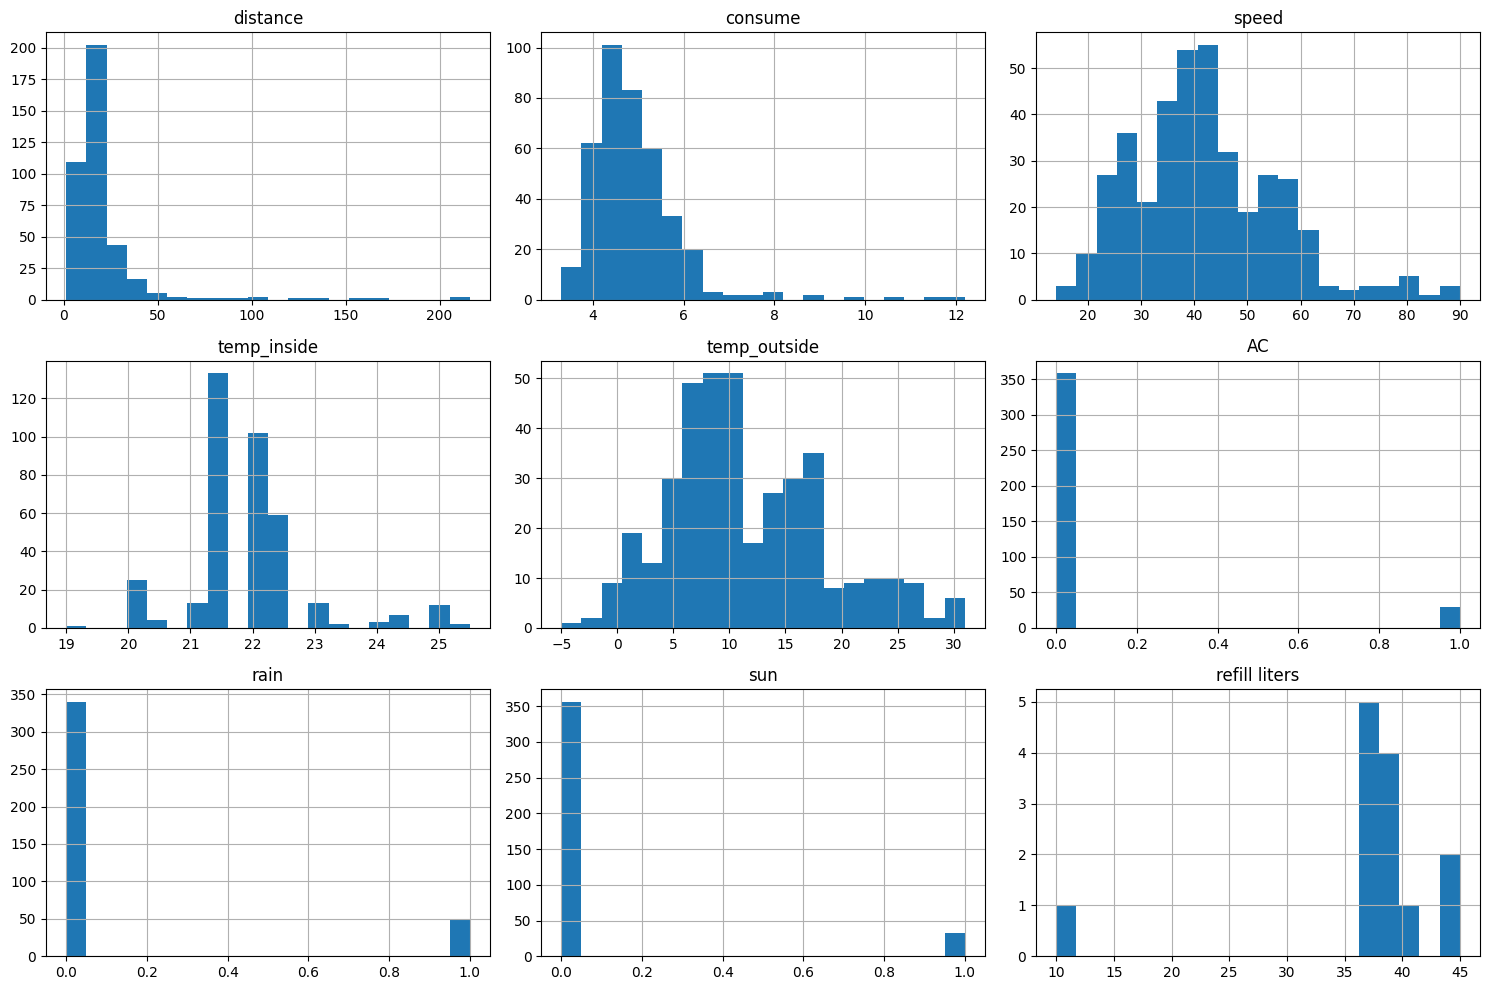

In [9]:
# Ambil hanya kolom numerik
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Plot semua dalam 1 cell
df_numeric.hist(figsize=(15, 10), bins=20)

plt.tight_layout()
plt.show()

In [10]:
# simple approach 
df.groupby('gas_type')['consume'].mean()

gas_type
E10     4.931250
SP98    4.899123
Name: consume, dtype: float64

In [11]:
df.groupby('gas_type')['consume'].agg(['mean', 'count', 'std'])

,mean,count,std
gas_type,,,
E10,4.931250,160,0.900956
SP98,4.899123,228,1.118408


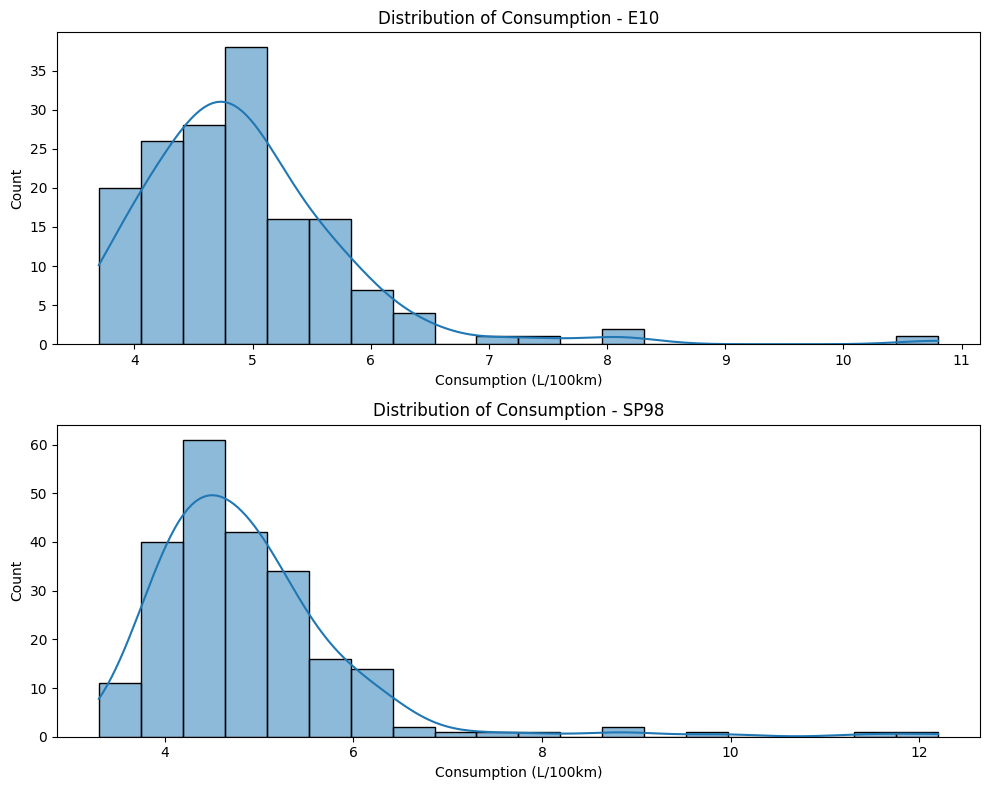

In [12]:
gas_types = df['gas_type'].unique()

plt.figure(figsize=(10, 4 * len(gas_types)))

for i, gas in enumerate(gas_types, 1):
    plt.subplot(len(gas_types), 1, i)
    
    subset = df[df['gas_type'] == gas]
    sns.histplot(subset['consume'], bins=20, kde=True)
    
    plt.title(f'Distribution of Consumption - {gas}')
    plt.xlabel('Consumption (L/100km)')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import ttest_ind

e10 = df[df['gas_type']=='E10']['consume']
sp98 = df[df['gas_type']=='SP98']['consume']

ttest_ind(e10, sp98)

TtestResult(statistic=np.float64(0.3011626300254617), pvalue=np.float64(0.7634526478628367), df=np.float64(386.0))